# 04 — Baseline Model (LightGBM)
**Input :** `dataset/processed/train_clean.csv`

**Pas de feature engineering** — uniquement les colonnes nettoyées.

**Metric :** MAE (Mean Absolute Error)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

TARGET = 'delivery_time_days'
N_FOLDS = 5
SEED = 42
print('Setup OK')

Setup OK


## 1. Chargement des données

In [2]:
train = pd.read_csv('dataset/processed/train_clean.csv')

print(f'Train : {train.shape}')
print(f'Colonnes : {list(train.columns)}')

Train : (85159, 16)
Colonnes : ['customer_city', 'customer_lat', 'customer_lng', 'seller_id', 'seller_city', 'seller_lat', 'seller_lng', 'quantity', 'price', 'freight_value', 'product_weight_g', 'volume_cm3', 'product_category_name_english', 'order_purchase_timestamp', 'order_approved_at', 'delivery_time_days']


## 2. Préparation des features
On utilise uniquement les colonnes disponibles après nettoyage, **sans feature engineering**.
Les timestamps et colonnes catégorielles à haute cardinalité sont exclues du baseline.

In [3]:
# Colonnes à exclure du baseline
EXCLUDE = ['order_purchase_timestamp', 'order_approved_at',
           'customer_city', 'seller_city', 'seller_id']

# Encodage label des catégorielles restantes
CAT_COLS = ['product_category_name_english']

df = train.copy()
for col in CAT_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

feature_cols = [c for c in df.columns if c not in EXCLUDE + [TARGET]]
X = df[feature_cols].values
y = df[TARGET].values

print(f'Features ({len(feature_cols)}) : {feature_cols}')
print(f'X shape : {X.shape}')

Features (10) : ['customer_lat', 'customer_lng', 'seller_lat', 'seller_lng', 'quantity', 'price', 'freight_value', 'product_weight_g', 'volume_cm3', 'product_category_name_english']
X shape : (85159, 10)


## 3. Cross-validation 5 folds — LightGBM

In [4]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

lgbm_params = {
    'objective'       : 'regression_l1',  # optimise MAE directement
    'metric'          : 'mae',
    'learning_rate'   : 0.05,
    'num_leaves'      : 63,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq'    : 5,
    'min_child_samples': 20,
    'verbose'         : -1,
    'seed'            : SEED,
}

fold_maes   = []
oof_preds   = np.zeros(len(y))
models      = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr, feature_name=feature_cols)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain, feature_name=feature_cols)

    model = lgb.train(
        lgbm_params,
        dtrain,
        num_boost_round=1000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )

    preds = model.predict(X_val)
    mae   = mean_absolute_error(y_val, preds)
    fold_maes.append(mae)
    oof_preds[val_idx] = preds
    models.append(model)

    print(f'Fold {fold} — MAE : {mae:.4f}  (best iter: {model.best_iteration})')

oof_mae = mean_absolute_error(y, oof_preds)
print(f'\nOOF MAE       : {oof_mae:.4f}')
print(f'Mean fold MAE : {np.mean(fold_maes):.4f} ± {np.std(fold_maes):.4f}')

Fold 1 — MAE : 4.7236  (best iter: 998)
Fold 2 — MAE : 4.6465  (best iter: 1000)
Fold 3 — MAE : 4.8308  (best iter: 997)
Fold 4 — MAE : 4.7414  (best iter: 998)
Fold 5 — MAE : 4.6004  (best iter: 998)

OOF MAE       : 4.7085
Mean fold MAE : 4.7085 ± 0.0797


## 4. Plot des métriques par fold

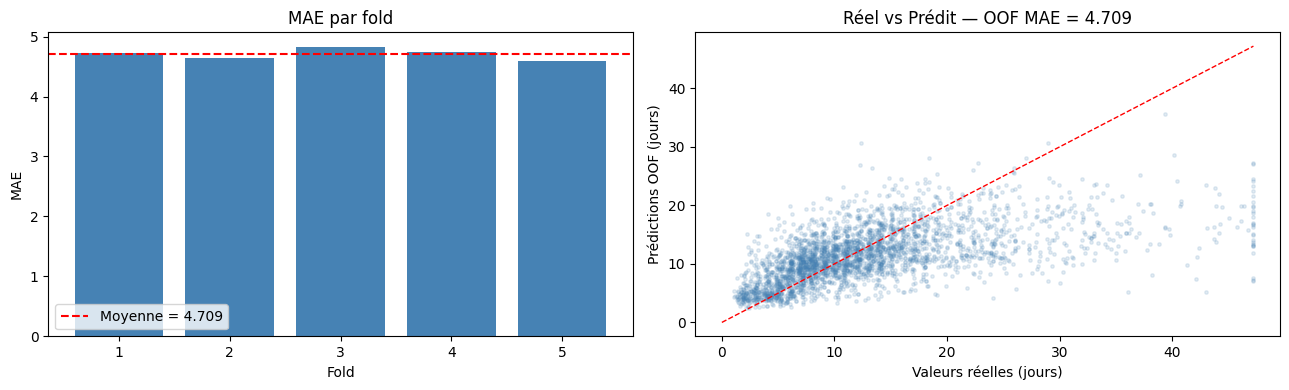

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# MAE par fold
axes[0].bar(range(1, N_FOLDS + 1), fold_maes, color='steelblue')
axes[0].axhline(np.mean(fold_maes), color='red', linestyle='--', label=f'Moyenne = {np.mean(fold_maes):.3f}')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE par fold')
axes[0].legend()

# OOF predictions vs target
sample_idx = np.random.choice(len(y), size=3000, replace=False)
axes[1].scatter(y[sample_idx], oof_preds[sample_idx], alpha=0.15, s=6, color='steelblue')
lims = [0, max(y.max(), oof_preds.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1)
axes[1].set_xlabel('Valeurs réelles (jours)')
axes[1].set_ylabel('Prédictions OOF (jours)')
axes[1].set_title(f'Réel vs Prédit — OOF MAE = {oof_mae:.3f}')

plt.tight_layout()
plt.show()

## 5. Feature importance

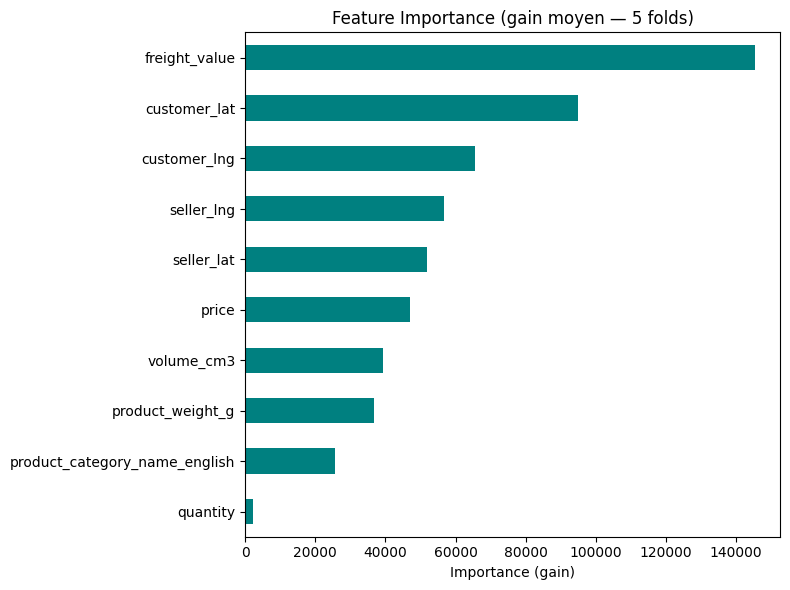


Top features :
freight_value                    145221.0
customer_lat                      94814.1
customer_lng                      65540.7
seller_lng                        56664.9
seller_lat                        51964.3
price                             46886.4
volume_cm3                        39429.3
product_weight_g                  36711.3
product_category_name_english     25676.2
quantity                           2232.7


In [6]:
# Importance moyenne sur tous les folds (gain)
importances = np.mean(
    [m.feature_importance(importance_type='gain') for m in models], axis=0
)
fi = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
fi.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Feature Importance (gain moyen — 5 folds)')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

print('\nTop features :')
print(fi[::-1].round(1).to_string())

---
## 6. Feature Engineering + nouveau modèle

Ajout des features : `distance_km`, `approval_delay_h`, temporelles (heure/dow/mois), target encoding vendeur et catégorie, fréquence villes.

In [7]:
import math

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

df2 = train.copy()

# --- distance_km ---
df2['distance_km'] = df2.apply(
    lambda r: haversine(r['customer_lat'], r['customer_lng'], r['seller_lat'], r['seller_lng']),
    axis=1
)

# --- timestamps ---
df2['purchase_ts'] = pd.to_datetime(df2['order_purchase_timestamp'])
df2['approved_ts'] = pd.to_datetime(df2['order_approved_at'])

df2['approval_delay_h'] = (df2['approved_ts'] - df2['purchase_ts']).dt.total_seconds() / 3600
df2['approval_delay_h'] = df2['approval_delay_h'].clip(0, df2['approval_delay_h'].quantile(0.99))

df2['purchase_hour'] = df2['purchase_ts'].dt.hour
df2['purchase_dow']  = df2['purchase_ts'].dt.dayofweek
df2['purchase_month']= df2['purchase_ts'].dt.month

# --- fréquence des villes ---
for col, new_col in [('customer_city', 'customer_city_freq'), ('seller_city', 'seller_city_freq')]:
    freq = df2[col].value_counts(normalize=True)
    df2[new_col] = df2[col].map(freq)

# --- label encoding catégorie ---
le2 = LabelEncoder()
df2['category_enc'] = le2.fit_transform(df2['product_category_name_english'].astype(str))

# --- features statiques (sans target encoding — calculé dans le fold) ---
STATIC_FEATS = [
    'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng',
    'quantity', 'price', 'freight_value', 'product_weight_g', 'volume_cm3',
    'category_enc',
    'distance_km',
    'approval_delay_h',
    'purchase_hour', 'purchase_dow', 'purchase_month',
    'customer_city_freq', 'seller_city_freq',
]

print(f'Features statiques : {len(STATIC_FEATS)}')
print(df2[STATIC_FEATS].describe().round(2))
print(f'Nulls : {df2[STATIC_FEATS].isnull().sum()[df2[STATIC_FEATS].isnull().sum()>0].to_dict()}')

Features statiques : 17
       customer_lat  customer_lng  seller_lat  seller_lng  quantity     price  \
count      85159.00      85159.00    85159.00    85159.00  85159.00  85159.00   
mean         -21.18        -46.18      -22.81      -47.25      0.73      4.37   
std            5.62          4.07        2.62        2.33      0.14      0.90   
min          -33.69        -72.67      -32.08      -63.89      0.69      0.62   
25%          -23.59        -48.16      -23.61      -48.83      0.69      3.71   
50%          -22.92        -46.63      -23.41      -46.76      0.69      4.38   
75%          -20.08        -43.58      -21.76      -46.52      0.69      4.94   
max           22.57        -23.58       -2.50      -34.86      3.04      8.82   

       freight_value  product_weight_g  volume_cm3  category_enc  distance_km  \
count       85159.00          85159.00    85159.00      85159.00     85159.00   
mean            2.89              6.71        8.86         39.66       604.69   
std

In [8]:
y2 = df2[TARGET].values
seller_ids = df2['seller_id'].values
categories  = df2['category_enc'].values

kf2 = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_maes2  = []
oof_preds2  = np.zeros(len(y2))
models2     = []

GLOBAL_MEAN = y2.mean()

for fold, (tr_idx, val_idx) in enumerate(kf2.split(df2), 1):
    # --- target encoding vendeur (uniquement sur le fold train) ---
    seller_mean = (
        df2.iloc[tr_idx].groupby('seller_id')[TARGET].mean()
    )
    df2['seller_mean_delivery'] = df2['seller_id'].map(seller_mean).fillna(GLOBAL_MEAN)

    # --- target encoding catégorie (sur le fold train) ---
    cat_mean = (
        df2.iloc[tr_idx].groupby('product_category_name_english')[TARGET].mean()
    )
    df2['category_mean_delivery'] = df2['product_category_name_english'].map(cat_mean).fillna(GLOBAL_MEAN)

    ALL_FEATS = STATIC_FEATS + ['seller_mean_delivery', 'category_mean_delivery']

    X_tr  = df2.iloc[tr_idx][ALL_FEATS].values
    X_val = df2.iloc[val_idx][ALL_FEATS].values
    y_tr  = y2[tr_idx]
    y_val = y2[val_idx]

    dtrain2 = lgb.Dataset(X_tr, label=y_tr, feature_name=ALL_FEATS)
    dval2   = lgb.Dataset(X_val, label=y_val, reference=dtrain2, feature_name=ALL_FEATS)

    model2 = lgb.train(
        lgbm_params,
        dtrain2,
        num_boost_round=1000,
        valid_sets=[dval2],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )

    preds2 = model2.predict(X_val)
    mae2   = mean_absolute_error(y_val, preds2)
    fold_maes2.append(mae2)
    oof_preds2[val_idx] = preds2
    models2.append(model2)

    print(f'Fold {fold} — MAE : {mae2:.4f}  (best iter: {model2.best_iteration})')

oof_mae2 = mean_absolute_error(y2, oof_preds2)
print(f'\nOOF MAE (engineered) : {oof_mae2:.4f}')
print(f'OOF MAE (baseline)   : {oof_mae:.4f}')
print(f'Gain                 : {oof_mae - oof_mae2:.4f} jours')
print(f'Nb features          : {len(ALL_FEATS)}')

Fold 1 — MAE : 4.4260  (best iter: 997)
Fold 2 — MAE : 4.3717  (best iter: 991)
Fold 3 — MAE : 4.5112  (best iter: 1000)
Fold 4 — MAE : 4.4823  (best iter: 994)
Fold 5 — MAE : 4.3003  (best iter: 1000)

OOF MAE (engineered) : 4.4183
OOF MAE (baseline)   : 4.7085
Gain                 : 0.2902 jours
Nb features          : 19


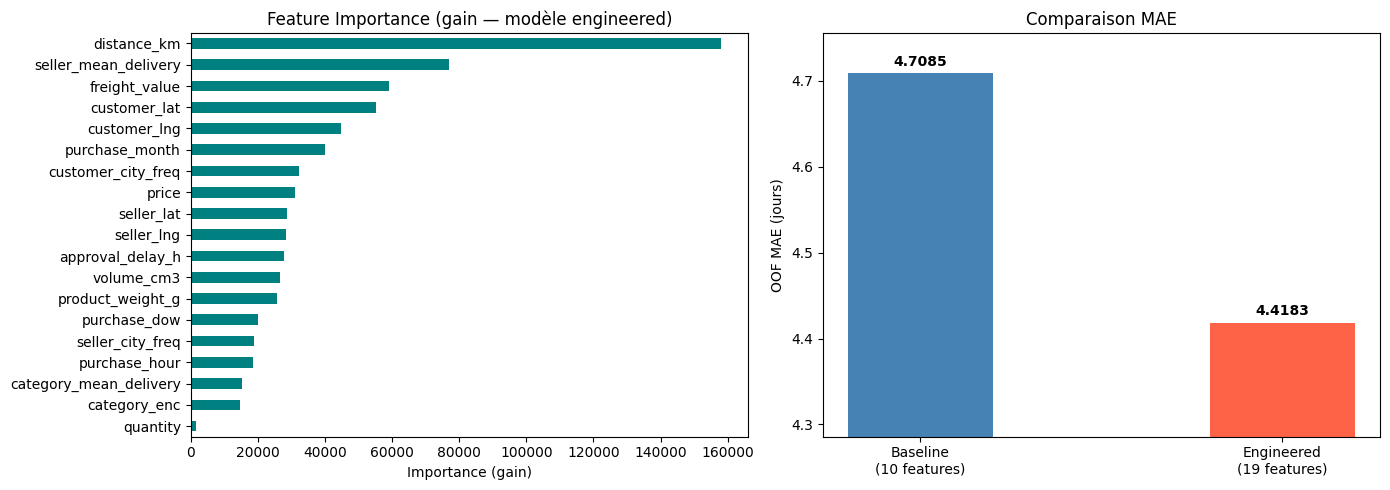


Feature importance ranking :
distance_km               158145.7
seller_mean_delivery       77069.5
freight_value              59115.6
customer_lat               55348.2
customer_lng               44822.0
purchase_month             40060.5
customer_city_freq         32300.8
price                      31079.3
seller_lat                 28751.9
seller_lng                 28424.3
approval_delay_h           27694.1
volume_cm3                 26754.8
product_weight_g           25790.8
purchase_dow               20020.5
seller_city_freq           18769.6
purchase_hour              18655.4
category_mean_delivery     15295.7
category_enc               14726.2
quantity                    1564.0


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Feature importance ---
importances2 = np.mean(
    [m.feature_importance(importance_type='gain') for m in models2], axis=0
)
fi2 = pd.Series(importances2, index=ALL_FEATS).sort_values(ascending=True)

fi2.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Feature Importance (gain — modèle engineered)')
axes[0].set_xlabel('Importance (gain)')

# --- Comparaison baseline vs engineered ---
labels = ['Baseline\n(10 features)', 'Engineered\n(19 features)']
values = [oof_mae, oof_mae2]
colors = ['steelblue', 'tomato']
bars = axes[1].bar(labels, values, color=colors, width=0.4)
axes[1].set_ylim(min(values) * 0.97, max(values) * 1.01)
axes[1].set_ylabel('OOF MAE (jours)')
axes[1].set_title('Comparaison MAE')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nFeature importance ranking :')
print(fi2[::-1].round(1).to_string())